Import the Required Libraries

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

Build a Sample Circuit

In [2]:
qc = QuantumCircuit(4)
qc.h(0)
for i in range(1, 4):
    qc.cx(0, i)
qc.x(0)
qc.cz(1, 2)
qc.ry(0.5, 3)
qc.measure_all()

print("Original circuit:")
qc.draw('mpl')
plt.show()

Original circuit:


Set Up the Simulator Backend

In [3]:
simulator = AerSimulator()
print("Basis gates supported by AerSimulator:")
print(simulator.target.operation_names)

Basis gates supported by AerSimulator:
dict_keys(['multiplexer', 'mcphase', 'save_amplitudes_sq', 'crz', 'sxdg', 'break_loop', 'set_unitary', 'u', 'r', 'mcr', 'mcry', 'swap', 'save_superop', 'cx', 'cu1', 'mcrx', 'superop', 'rzx', 'set_superop', 'u1', 'cu2', 'ryy', 'u2', 'cp', 'kraus', 'u3', 'y', 'mcu3', 'save_stabilizer', 'if_else', 'save_density_matrix', 'csx', 'tdg', 'save_amplitudes', 'save_statevector', 'mcsx', 'mcz', 'while_loop', 'cu3', 'save_matrix_product_state', 'switch_case', 'quantum_channel', 't', 'cry', 'p', 'ccx', 'mcu1', 'set_statevector', 'save_expval_var', 'h', 'ccz', 'save_probabilities_dict', 'mcswap', 'save_probabilities', 'cu', 'set_stabilizer', 'cz', 'rzz', 'save_expval', 'save_unitary', 'continue_loop', 'save_clifford', 'qerror_loc', 'mcp', 'save_state', 'set_matrix_product_state', 'mcu', 'mcx_gray', 'sdg', 'mcx', 'cy', 'z', 'ry', 'mcrz', 'initialize', 'roerror', 'rx', 'reset', 'crx', 'unitary', 'delay', 'for_loop', 'measure', 'rxx', 'save_statevector_dict', 'csw

Transpile with Optimization Level 0

Level 0 - Gate count: OrderedDict({'measure': 4, 'cx': 3, 'h': 1, 'cz': 1, 'x': 1, 'ry': 1, 'barrier': 1})
Level 0 - Depth: 6


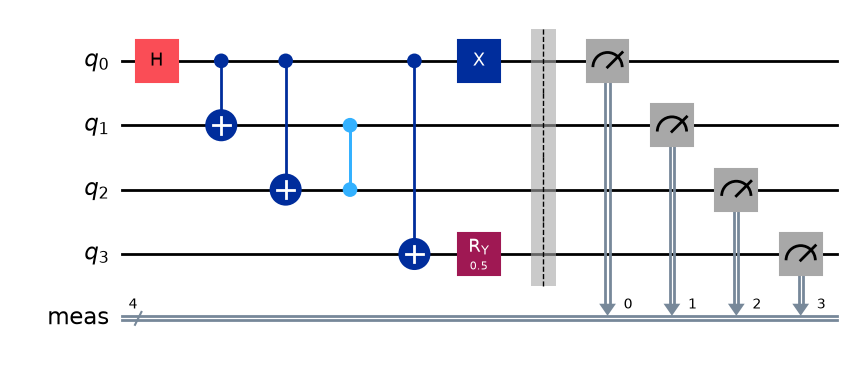

In [4]:
qc_lv0 = transpile(qc, backend=simulator, optimization_level=0)
print(f"Level 0 - Gate count: {qc_lv0.count_ops()}")
print(f"Level 0 - Depth: {qc_lv0.depth()}")
qc_lv0.draw('mpl')

Transpile with Optimization Level 1

Level 1 - Gate count: OrderedDict({'measure': 4, 'cx': 3, 'h': 1, 'cz': 1, 'x': 1, 'ry': 1, 'barrier': 1})
Level 1 - Depth: 6


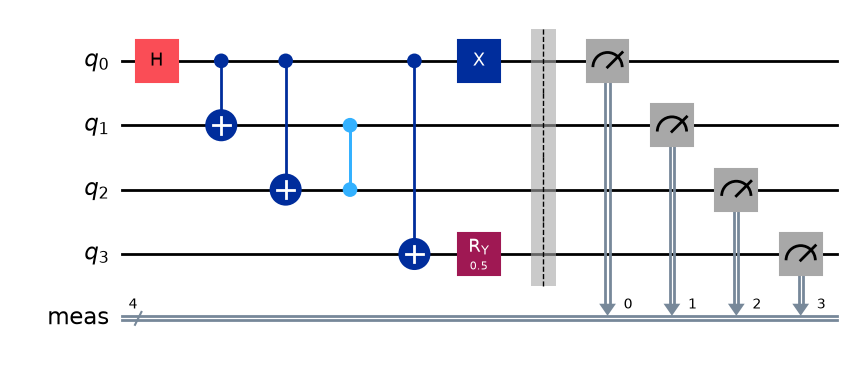

In [5]:
qc_lv1 = transpile(qc, backend=simulator, optimization_level=1)
print(f"Level 1 - Gate count: {qc_lv1.count_ops()}")
print(f"Level 1 - Depth: {qc_lv1.depth()}")
qc_lv1.draw('mpl')

Transpile with Optimization Level 2

Level 2 - Gate count: OrderedDict({'measure': 4, 'cx': 3, 'h': 1, 'cz': 1, 'x': 1, 'ry': 1, 'barrier': 1})
Level 2 - Depth: 6


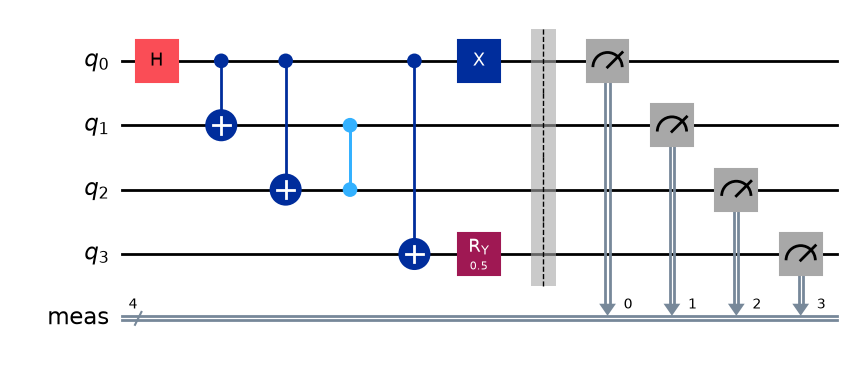

In [6]:
qc_lv2 = transpile(qc, backend=simulator, optimization_level=2)
print(f"Level 2 - Gate count: {qc_lv2.count_ops()}")
print(f"Level 2 - Depth: {qc_lv2.depth()}")
qc_lv2.draw('mpl')

Transpile with Optimization Level 3

Level 3 - Gate count: OrderedDict({'measure': 4, 'cx': 3, 'h': 1, 'cz': 1, 'x': 1, 'ry': 1, 'barrier': 1})
Level 3 - Depth: 6


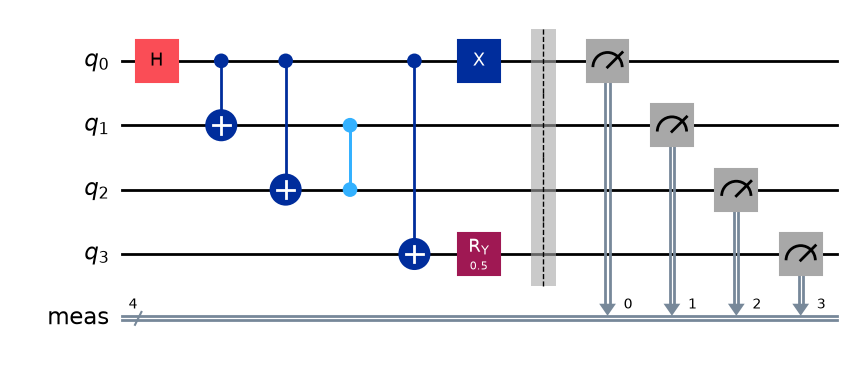

In [7]:
qc_lv3 = transpile(qc, backend=simulator, optimization_level=3)
print(f"Level 3 - Gate count: {qc_lv3.count_ops()}")
print(f"Level 3 - Depth: {qc_lv3.depth()}")
qc_lv3.draw('mpl')

Compare the Results Side by Side

In [8]:
print("=" * 50)
print("Comparison of Optimization Levels")
print("=" * 50)

levels = [0, 1, 2, 3]
circuits = [qc_lv0, qc_lv1, qc_lv2, qc_lv3]

for level, circ in zip(levels, circuits):
    ops = circ.count_ops()
    depth = circ.depth()
    print(f"Level {level}: {sum(ops.values())} gates, depth = {depth}")
    print(f"  Gate breakdown: {ops}")
    print()

Comparison of Optimization Levels
Level 0: 12 gates, depth = 6
  Gate breakdown: OrderedDict({'measure': 4, 'cx': 3, 'h': 1, 'cz': 1, 'x': 1, 'ry': 1, 'barrier': 1})

Level 1: 12 gates, depth = 6
  Gate breakdown: OrderedDict({'measure': 4, 'cx': 3, 'h': 1, 'cz': 1, 'x': 1, 'ry': 1, 'barrier': 1})

Level 2: 12 gates, depth = 6
  Gate breakdown: OrderedDict({'measure': 4, 'cx': 3, 'h': 1, 'cz': 1, 'x': 1, 'ry': 1, 'barrier': 1})

Level 3: 12 gates, depth = 6
  Gate breakdown: OrderedDict({'measure': 4, 'cx': 3, 'h': 1, 'cz': 1, 'x': 1, 'ry': 1, 'barrier': 1})



Verify the Results Are Correct

In [9]:
shots = 1024

for level, circ in enumerate([qc_lv0, qc_lv1, qc_lv2, qc_lv3]):
    job = simulator.run(circ, shots=shots)
    counts = job.result().get_counts()
    print(f"Level {level} - Most common outcome: {max(counts, key=counts.get)}")

Level 0 - Most common outcome: 1110
Level 1 - Most common outcome: 1110
Level 2 - Most common outcome: 0001
Level 3 - Most common outcome: 1110
